Customer Dataset 

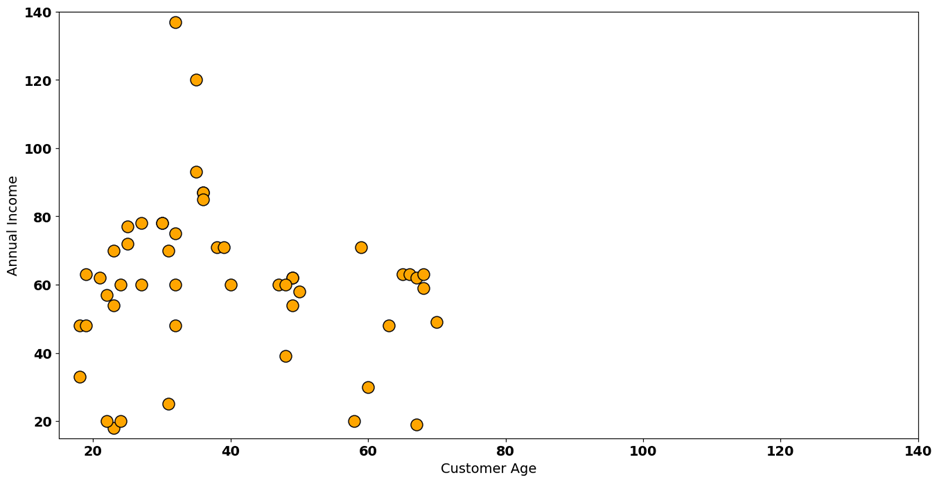

---
Customer Standardized Dataset

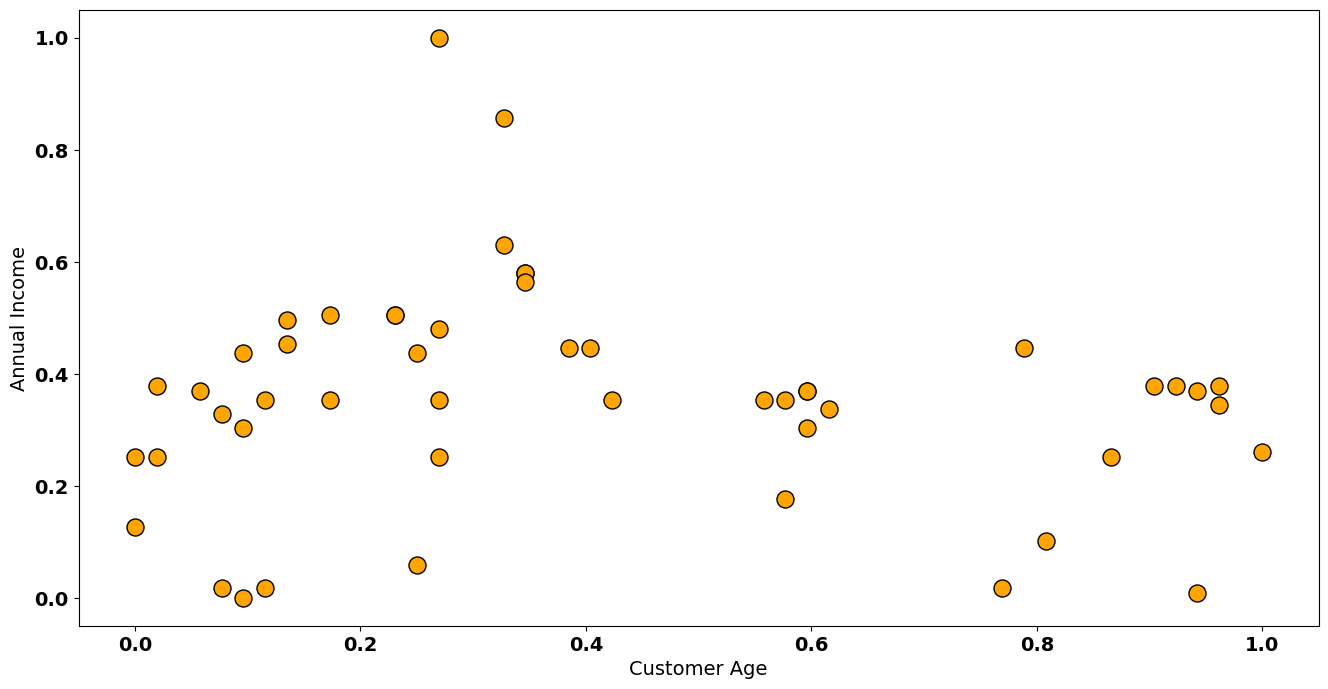

---
K-Means solution on Dataset

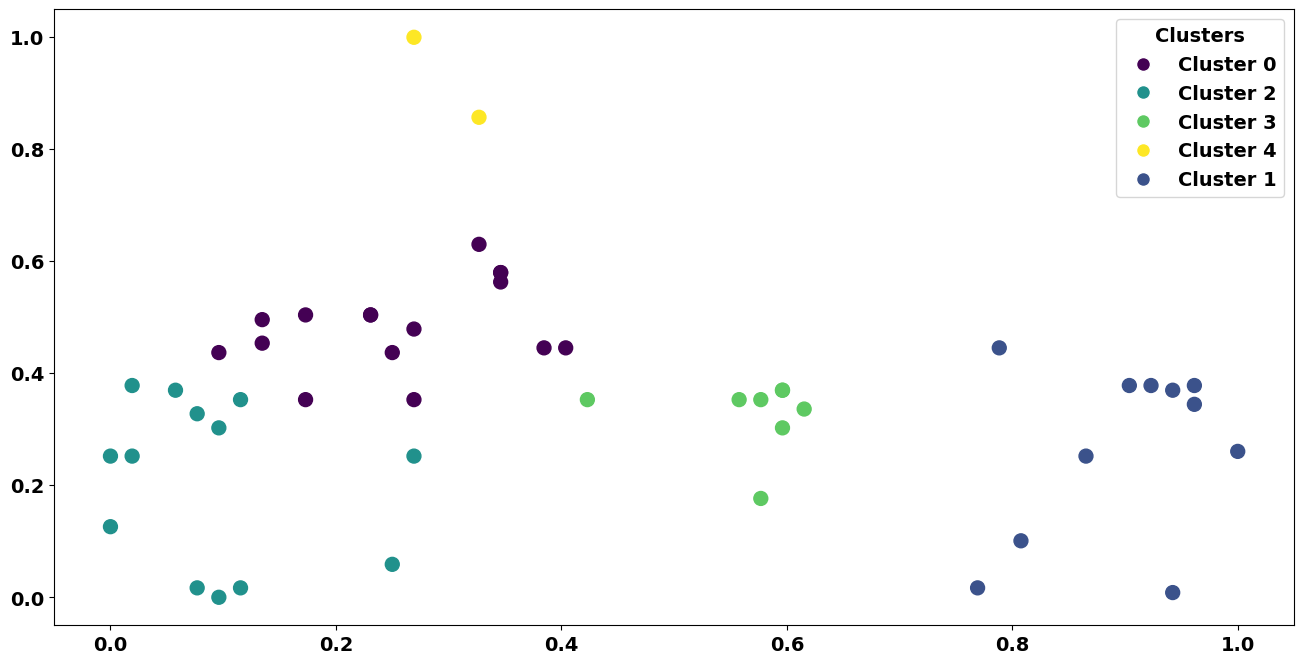

---
Mean-Shift Solution 

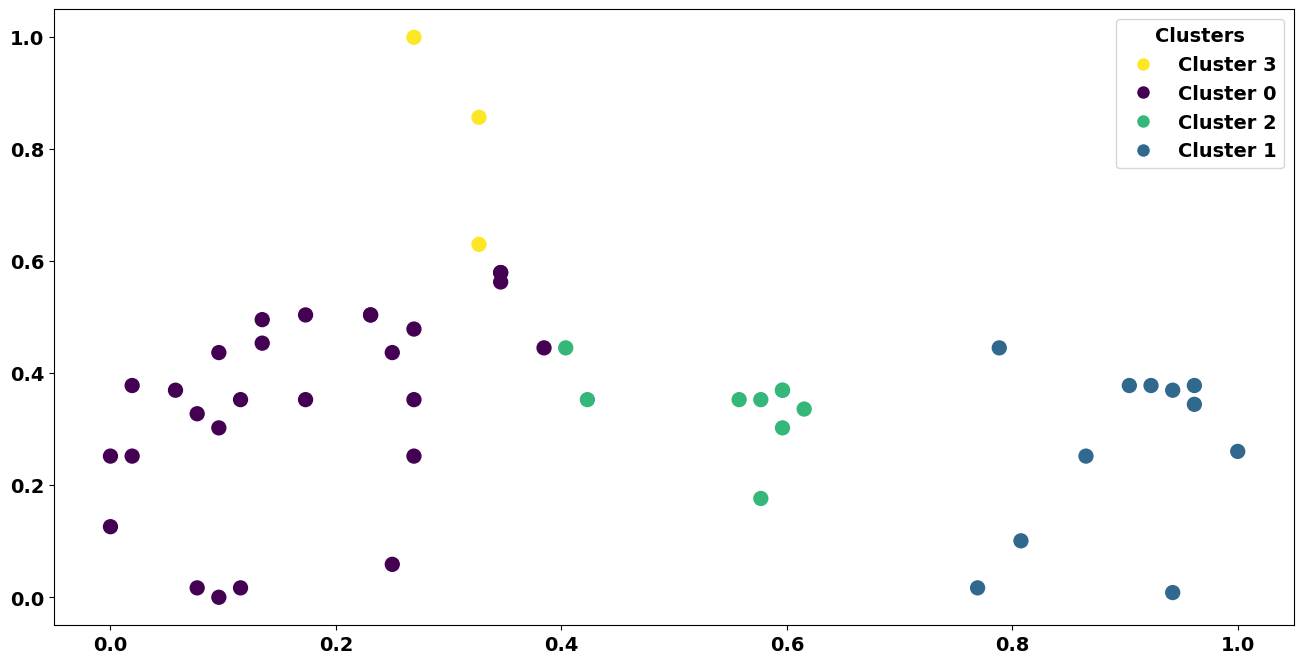

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
wholesale_customers = pd.read_csv('Wholesale customers data.csv')

wholesale_customers.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


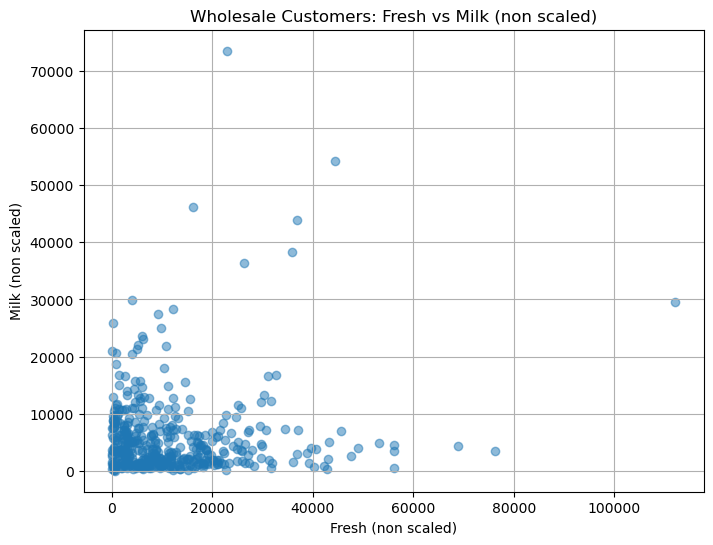

In [77]:
selected_dataset = wholesale_customers[['Fresh', 'Milk']].values

plt.figure(figsize=(8, 6))
plt.scatter(selected_dataset[:, 0], selected_dataset[:, 1], alpha=0.5)
plt.xlabel('Fresh (non scaled)')
plt.ylabel('Milk (non scaled)')
plt.title('Wholesale Customers: Fresh vs Milk (non scaled)')
plt.grid(True)
plt.show()

In [78]:
from sklearn.preprocessing import MinMaxScaler

mmc = MinMaxScaler()
scaled_dataset = mmc.fit_transform(
    wholesale_customers[['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
)

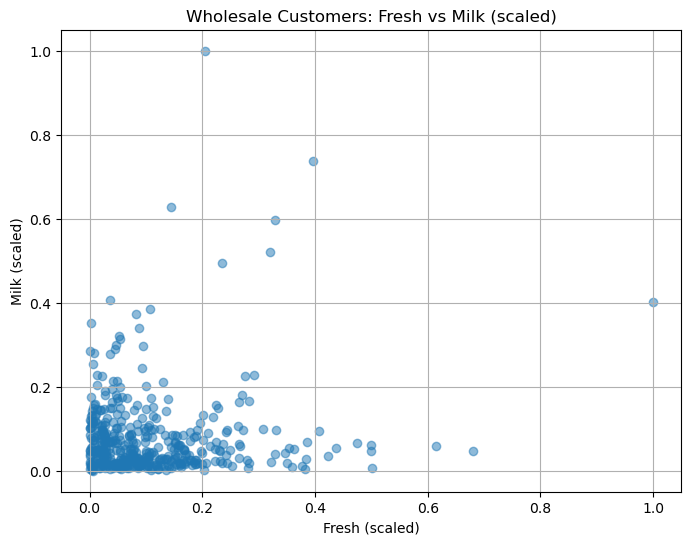

In [79]:
plt.figure(figsize=(8, 6))
plt.scatter(scaled_dataset[:, 0], scaled_dataset[:, 1], alpha=0.5)
plt.xlabel('Fresh (scaled)')
plt.ylabel('Milk (scaled)')
plt.title('Wholesale Customers: Fresh vs Milk (scaled)')
plt.grid(True)
plt.show()

In [80]:
from sklearn.cluster import MeanShift, estimate_bandwidth

bandwith_estimation = estimate_bandwidth(scaled_dataset)

In [81]:
meanshiftmodel = MeanShift(bandwidth=bandwith_estimation)
wholesale_customers['meanshift_clustering'] = meanshiftmodel.fit_predict(
    scaled_dataset
)

In [82]:
len(np.unique(meanshiftmodel.labels_)) # Number of clusters

15

In [83]:
wholesale_customers['meanshift_clustering'].value_counts()

meanshift_clustering
0     387
1      26
4      14
12      2
8       1
3       1
6       1
14      1
10      1
11      1
9       1
2       1
5       1
7       1
13      1
Name: count, dtype: int64

In [92]:
meanshiftmodel = MeanShift(bandwidth=bandwith_estimation+0.1)
wholesale_customers['meanshift_clustering_extra_band'] = meanshiftmodel.fit_predict(
 scaled_dataset
)

In [93]:
wholesale_customers['meanshift_clustering_extra_band'].value_counts()

meanshift_clustering_extra_band
0    422
5      5
1      3
9      2
8      2
2      2
7      1
6      1
3      1
4      1
Name: count, dtype: int64

In [86]:
outlier_clusters = (
    wholesale_customers['meanshift_clustering'].value_counts().loc[
        wholesale_customers['meanshift_clustering'].value_counts() <= 3
    ]
).index

clustering_solution = wholesale_customers.loc[~wholesale_customers.meanshift_clustering.isin(outlier_clusters)]



In [87]:
clustering_solution.groupby(['meanshift_clustering']).mean().iloc[:,2:]

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,meanshift_clustering_extra_band
meanshift_clustering,,,,,,,
0,10375.695090,4395.824289,5936.320413,2628.695090,1881.733850,1197.503876,0.000000
1,5839.807692,16314.653846,25944.307692,1782.884615,12988.076923,2135.884615,0.807692
4,51177.500000,3455.785714,5107.214286,6884.214286,859.357143,2738.428571,0.142857


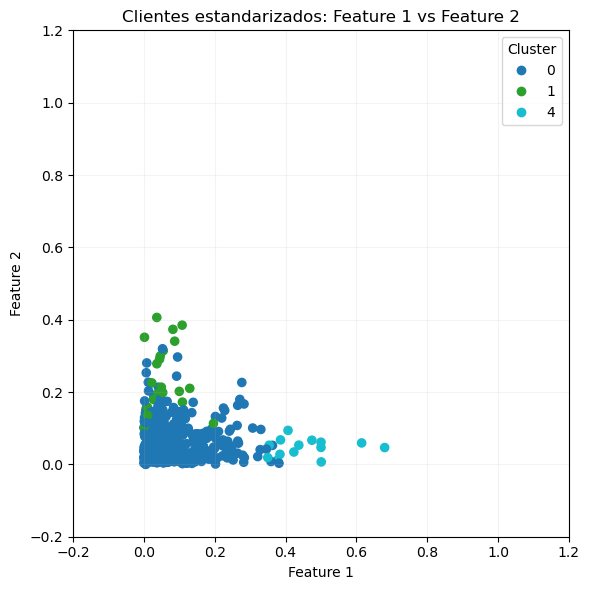

In [89]:
plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    X[:, 0], X[:, 1],
    c=clustering_solution['meanshift_clustering'],
    cmap='tab10',
    s=35,
    label='Clientes'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.title('Clientes estandarizados: Feature 1 vs Feature 2')
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()